In [7]:
# Cell 1 — Imports and path setup
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data.load import load_config, load_dataset

# Plot styling
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("husl")

print("✅ Imports OK")

✅ Imports OK


In [9]:
# Cell 2 — Load dataset using load.py
from pathlib import Path

# Resolve project root regardless of where notebook is run from
PROJECT_ROOT = Path("..").resolve()

config = load_config(PROJECT_ROOT / "config/config.yaml")

# Override paths to be absolute
config["dataset"]["raw_path"] = str(PROJECT_ROOT / "data/raw")

train_df, test_df, rul = load_dataset(config)

[load] Train shape : (20631, 26)
[load] Test shape  : (13096, 26)
[load] RUL entries : 100


In [10]:
# Cell 3 - Basic Dataset Inspection
print("=== TRAIN ===")
print(f"Shape     : {train_df.shape}")
print(f"Engines   : { train_df['unit'].nunique()}")
print(f"Cycles range  : {train_df['cycle'].min()} - {train_df['cycle'].max()}")
print(f"Columns  : {list(train_df.columns)}")

print("\n=== TEST ===")
print(f"Shape     : {test_df.shape}")
print(f"Engines   : { test_df['unit'].nunique()}")

print("\n=== RUL ===")
print(f"Min RUL  : {rul.min()}")
print(f"Max RUL  : {rul.max()}")
print(f"Mean RUL : {rul.mean():.1f}")


=== TRAIN ===
Shape     : (20631, 26)
Engines   : 100
Cycles range  : 1 - 362
Columns  : ['unit', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']

=== TEST ===
Shape     : (13096, 26)
Engines   : 100

=== RUL ===
Min RUL  : 7
Max RUL  : 145
Mean RUL : 75.5


=== ENGINE LIFECYCLE STATISTICS ===
Shortest lifespan : 128 cycles
Longest lifespan  : 362 cycles
Mean lifespan     : 206.3 cycles
Median lifespan   : 199.0 cycles
Std deviation     : 46.3 cycles


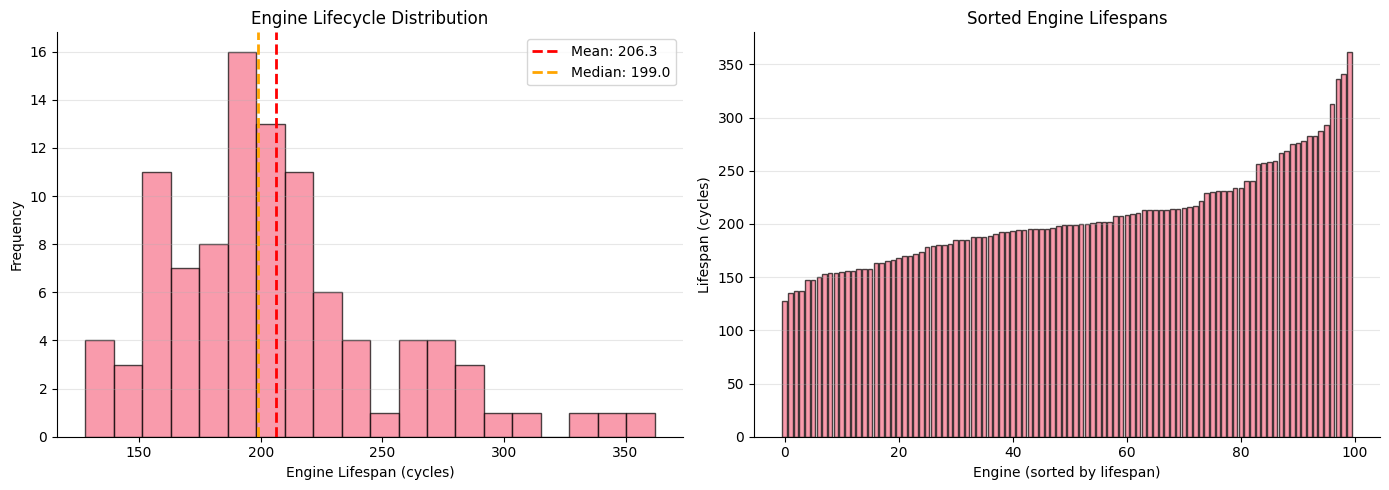


✅ Lifespan range: 234 cycles


In [11]:
# Cell 4 — Engine Lifecycle Distribution
"""
Purpose: Analyze engine lifespan distribution to understand degradation trajectory range.
Why: Knowing lifecycle variability helps set expectations for RUL prediction range.
"""

# Calculate max cycle (lifespan) per engine
engine_lifespans = train_df.groupby("unit")["cycle"].max().sort_values()

print("=== ENGINE LIFECYCLE STATISTICS ===")
print(f"Shortest lifespan : {engine_lifespans.min()} cycles")
print(f"Longest lifespan  : {engine_lifespans.max()} cycles")
print(f"Mean lifespan     : {engine_lifespans.mean():.1f} cycles")
print(f"Median lifespan   : {engine_lifespans.median():.1f} cycles")
print(f"Std deviation     : {engine_lifespans.std():.1f} cycles")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(engine_lifespans, bins=20, edgecolor="black", alpha=0.7)
axes[0].axvline(engine_lifespans.mean(), color="red", linestyle="--", linewidth=2, label=f"Mean: {engine_lifespans.mean():.1f}")
axes[0].axvline(engine_lifespans.median(), color="orange", linestyle="--", linewidth=2, label=f"Median: {engine_lifespans.median():.1f}")
axes[0].set_xlabel("Engine Lifespan (cycles)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Engine Lifecycle Distribution")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Sorted bar chart
axes[1].bar(range(len(engine_lifespans)), engine_lifespans.values, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Engine (sorted by lifespan)")
axes[1].set_ylabel("Lifespan (cycles)")
axes[1].set_title("Sorted Engine Lifespans")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Lifespan range: {engine_lifespans.max() - engine_lifespans.min()} cycles")

=== SENSOR STATISTICS (across all cycles) ===
               mean     std       min       max  variance    range
sensor_1    518.670   0.000   518.670   518.670     0.000    0.000
sensor_2    642.681   0.500   641.210   644.530     0.250    3.320
sensor_3   1590.523   6.131  1571.040  1616.910    37.591   45.870
sensor_4   1408.934   9.001  1382.250  1441.490    81.011   59.240
sensor_5     14.620   0.000    14.620    14.620     0.000    0.000
sensor_6     21.610   0.001    21.600    21.610     0.000    0.010
sensor_7    553.368   0.885   549.850   556.060     0.783    6.210
sensor_8   2388.097   0.071  2387.900  2388.560     0.005    0.660
sensor_9   9065.243  22.083  9021.730  9244.590   487.654  222.860
sensor_10     1.300   0.000     1.300     1.300     0.000    0.000
sensor_11    47.541   0.267    46.850    48.530     0.071    1.680
sensor_12   521.413   0.738   518.690   523.380     0.544    4.690
sensor_13  2388.096   0.072  2387.880  2388.560     0.005    0.680
sensor_14  8143.

/var/folders/60/52ssn0g963lfqt69krdb04840000gn/T/ipykernel_83226/3884454848.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(sensor_ranges_norm.values, labels=sensor_cols, showfliers=False)


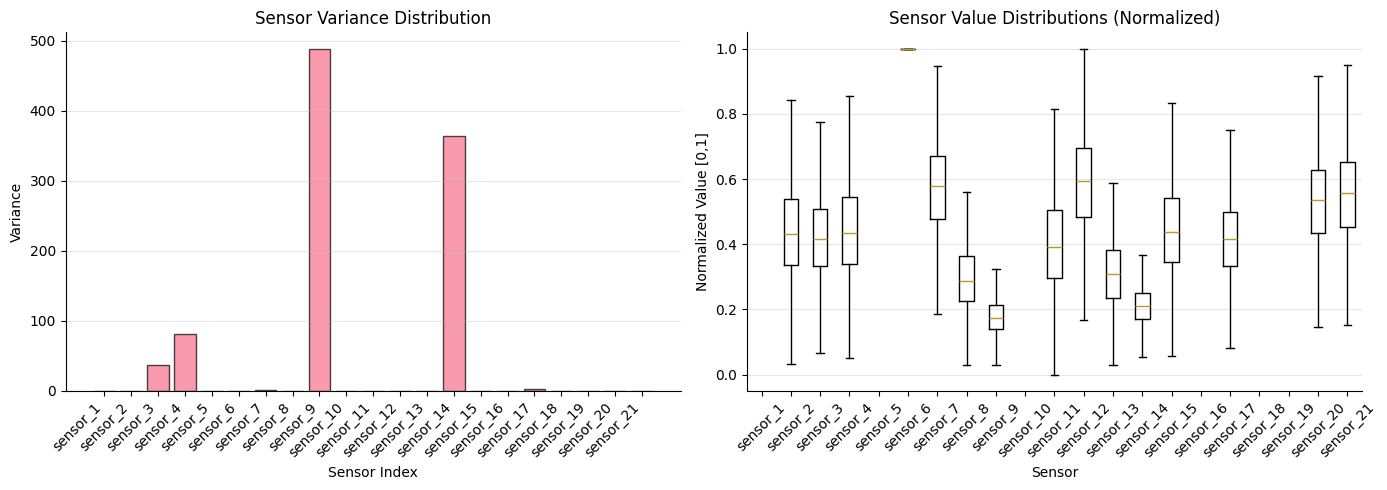

In [12]:
# Cell 5 — Sensor Statistics
"""
Purpose: Analyze sensor ranges and variances to identify informative vs. flat sensors.
Why: Sensors with zero variance provide no predictive signal and should be excluded.
     High variance sensors may indicate degradation patterns.
"""

# Extract sensor columns (exclude unit, cycle, operational settings)
sensor_cols = [col for col in train_df.columns if col.startswith("s")]

# Compute statistics per sensor
sensor_stats = train_df[sensor_cols].describe().T
sensor_stats["variance"] = train_df[sensor_cols].var()
sensor_stats["range"] = sensor_stats["max"] - sensor_stats["min"]

print("=== SENSOR STATISTICS (across all cycles) ===")
print(sensor_stats[["mean", "std", "min", "max", "variance", "range"]].round(3))

# Identify flat sensors (zero or near-zero variance)
flat_threshold = 1e-6
flat_sensors = sensor_stats[sensor_stats["variance"] < flat_threshold].index.tolist()

print(f"\n⚠️  Flat sensors (variance < {flat_threshold}): {flat_sensors}")
print(f"✅ Active sensors: {len(sensor_cols) - len(flat_sensors)} / {len(sensor_cols)}")

# Visualization: Sensor variance distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of sensor variances
axes[0].bar(range(len(sensor_stats)), sensor_stats["variance"].values, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Sensor Index")
axes[0].set_ylabel("Variance")
axes[0].set_title("Sensor Variance Distribution")
axes[0].set_xticks(range(len(sensor_stats)))
axes[0].set_xticklabels(sensor_stats.index, rotation=45, ha="right")
axes[0].grid(axis="y", alpha=0.3)

# Box plot of sensor ranges (normalized)
sensor_ranges_norm = (train_df[sensor_cols] - train_df[sensor_cols].min()) / (train_df[sensor_cols].max() - train_df[sensor_cols].min())
axes[1].boxplot(sensor_ranges_norm.values, labels=sensor_cols, showfliers=False)
axes[1].set_xlabel("Sensor")
axes[1].set_ylabel("Normalized Value [0,1]")
axes[1].set_title("Sensor Value Distributions (Normalized)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

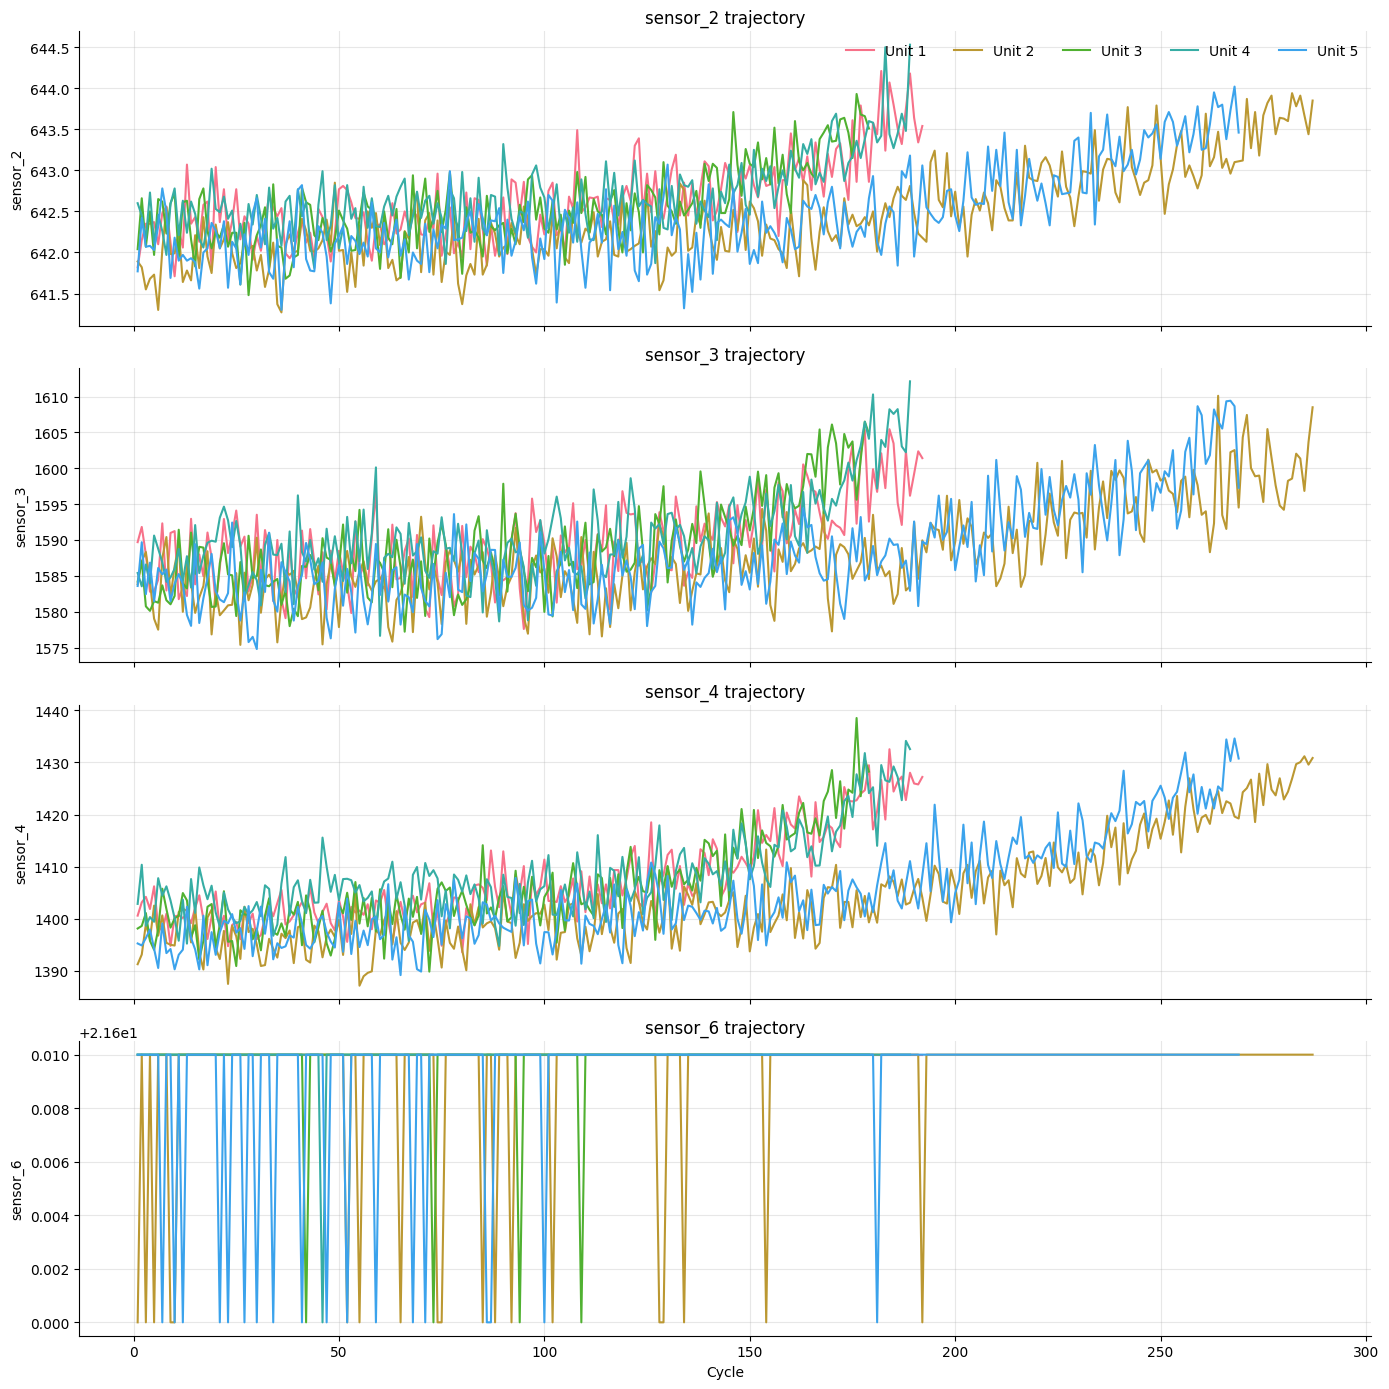

In [19]:
# Cell 6 — Multi-engine Sensor Trajectories
"""
Purpose: Compare degradation trajectories across engines for selected sensors.
Input shape: train_df with columns ['unit', 'cycle', sensor columns], one row per cycle.
Output shape: Matplotlib figure with one subplot per sensor and one line per engine.
Assumptions: 'unit' and 'cycle' exist; sensor columns are prefixed with 's'.
Failure conditions: Raises ValueError if no valid sensors or engines are available.
"""

# 1) Pick 3-5 engine unit numbers to plot
sample_engines = sorted(train_df["unit"].unique())[:5]

# Choose sensors from non-flat set discovered in Cell 5 (fallback: all sensors if flat_sensors not defined)
all_sensor_cols = [col for col in train_df.columns if col.startswith("s")]
non_flat_cols = [s for s in all_sensor_cols if "flat_sensors" not in locals() or s not in flat_sensors]
selected_sensors = non_flat_cols[:4]  # 3-5 sensors can also be used; here 4 sensors

if len(sample_engines) < 3:
    raise ValueError("Need at least 3 engines to compare trajectories.")
if len(selected_sensors) == 0:
    raise ValueError("No sensor columns available for plotting.")

# 4) One subplot per sensor, one line per engine
fig, axes = plt.subplots(len(selected_sensors), 1, figsize=(14, 3.5 * len(selected_sensors)), sharex=True)

# Handle single-sensor case
if len(selected_sensors) == 1:
    axes = [axes]

for i, sensor in enumerate(selected_sensors):
    ax = axes[i]
    for engine in sample_engines:
        # 2) Filter train_df by unit number
        engine_data = train_df[train_df["unit"] == engine].sort_values("cycle")

        # 3) Plot cycle on x-axis, sensor value on y-axis
        ax.plot(engine_data["cycle"], engine_data[sensor], linewidth=1.5, label=f"Unit {engine}")

    ax.set_title(f"{sensor} trajectory")
    ax.set_ylabel(sensor)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Cycle")
axes[0].legend(ncol=min(5, len(sample_engines)), frameon=False, loc="upper right")

plt.tight_layout()
plt.show()

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


=== SENSOR-RUL CORRELATION ===
sensor_6    -0.128
sensor_14   -0.307
sensor_9    -0.390
sensor_13   -0.563
sensor_8    -0.564
sensor_3    -0.585
sensor_17   -0.606
sensor_2    -0.606
sensor_20    0.629
sensor_21    0.636
sensor_15   -0.643
sensor_7     0.657
sensor_12    0.672
sensor_4    -0.679
sensor_11   -0.696
sensor_1       NaN
sensor_5       NaN
sensor_10      NaN
sensor_16      NaN
sensor_18      NaN
sensor_19      NaN
Name: rul, dtype: float64

Top 5 degradation-sensitive sensors:
  sensor_11: -0.696
  sensor_4: -0.679
  sensor_12: 0.672
  sensor_7: 0.657
  sensor_15: -0.643


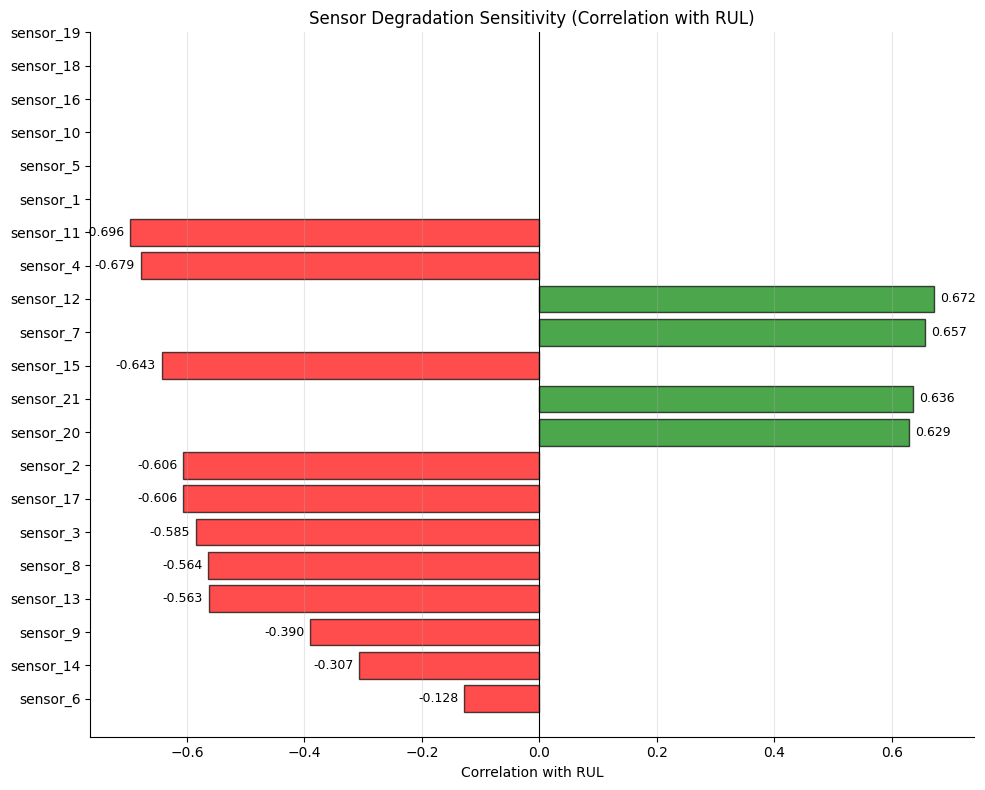

In [21]:
# Cell 7 — Sensor-RUL Correlation Analysis
"""
Purpose: Quantify how strongly each sensor correlates with RUL (degradation sensitivity).
Input shape: train_df with columns ['unit', 'cycle', 'sX' for sensors], one row per cycle.
Output shape: Correlation coefficients (21,), sorted by absolute value.
Assumptions: All 21 sensors are present; unit and cycle are valid.
Failure conditions: Raises ValueError if sensors or RUL cannot be computed.
"""

# 1) Add RUL column to train_df using merge (efficient, no apply+lambda)
max_cycles = train_df.groupby("unit")["cycle"].max().reset_index()
max_cycles.columns = ["unit", "max_cycle"]
train_df_rul = train_df.merge(max_cycles, on="unit")
train_df_rul["rul"] = train_df_rul["max_cycle"] - train_df_rul["cycle"]

# 2) Extract all 21 sensors and compute correlations
all_sensor_cols = [col for col in train_df.columns if col.startswith("s")]
correlations = train_df_rul[all_sensor_cols + ["rul"]].corr()["rul"].drop("rul")

# 3) Sort by absolute correlation (both positive and negative are informative)
correlations_sorted = correlations.sort_values(key=abs, ascending=True)

print("=== SENSOR-RUL CORRELATION ===")
print(correlations_sorted.round(3))
print(f"\nTop 5 degradation-sensitive sensors:")
for sensor, corr in correlations_sorted.abs().nlargest(5).items():
    print(f"  {sensor}: {correlations[sensor]:.3f}")

# 4) Plot horizontal bar chart with color coding (positive=green, negative=red)
fig, ax = plt.subplots(figsize=(10, 8))

colors = ["green" if x > 0 else "red" for x in correlations_sorted.values]
bars = ax.barh(range(len(correlations_sorted)), correlations_sorted.values, color=colors, alpha=0.7, edgecolor="black")

ax.set_yticks(range(len(correlations_sorted)))
ax.set_yticklabels(correlations_sorted.index)
ax.set_xlabel("Correlation with RUL")
ax.set_title("Sensor Degradation Sensitivity (Correlation with RUL)")
ax.axvline(0, color="black", linewidth=0.8)
ax.grid(axis="x", alpha=0.3)

# Add value labels on bars
for i, (sensor, corr) in enumerate(correlations_sorted.items()):
    ax.text(corr + 0.01 if corr > 0 else corr - 0.01, i, f"{corr:.3f}", 
            va="center", ha="left" if corr > 0 else "right", fontsize=9)

plt.tight_layout()
plt.show()

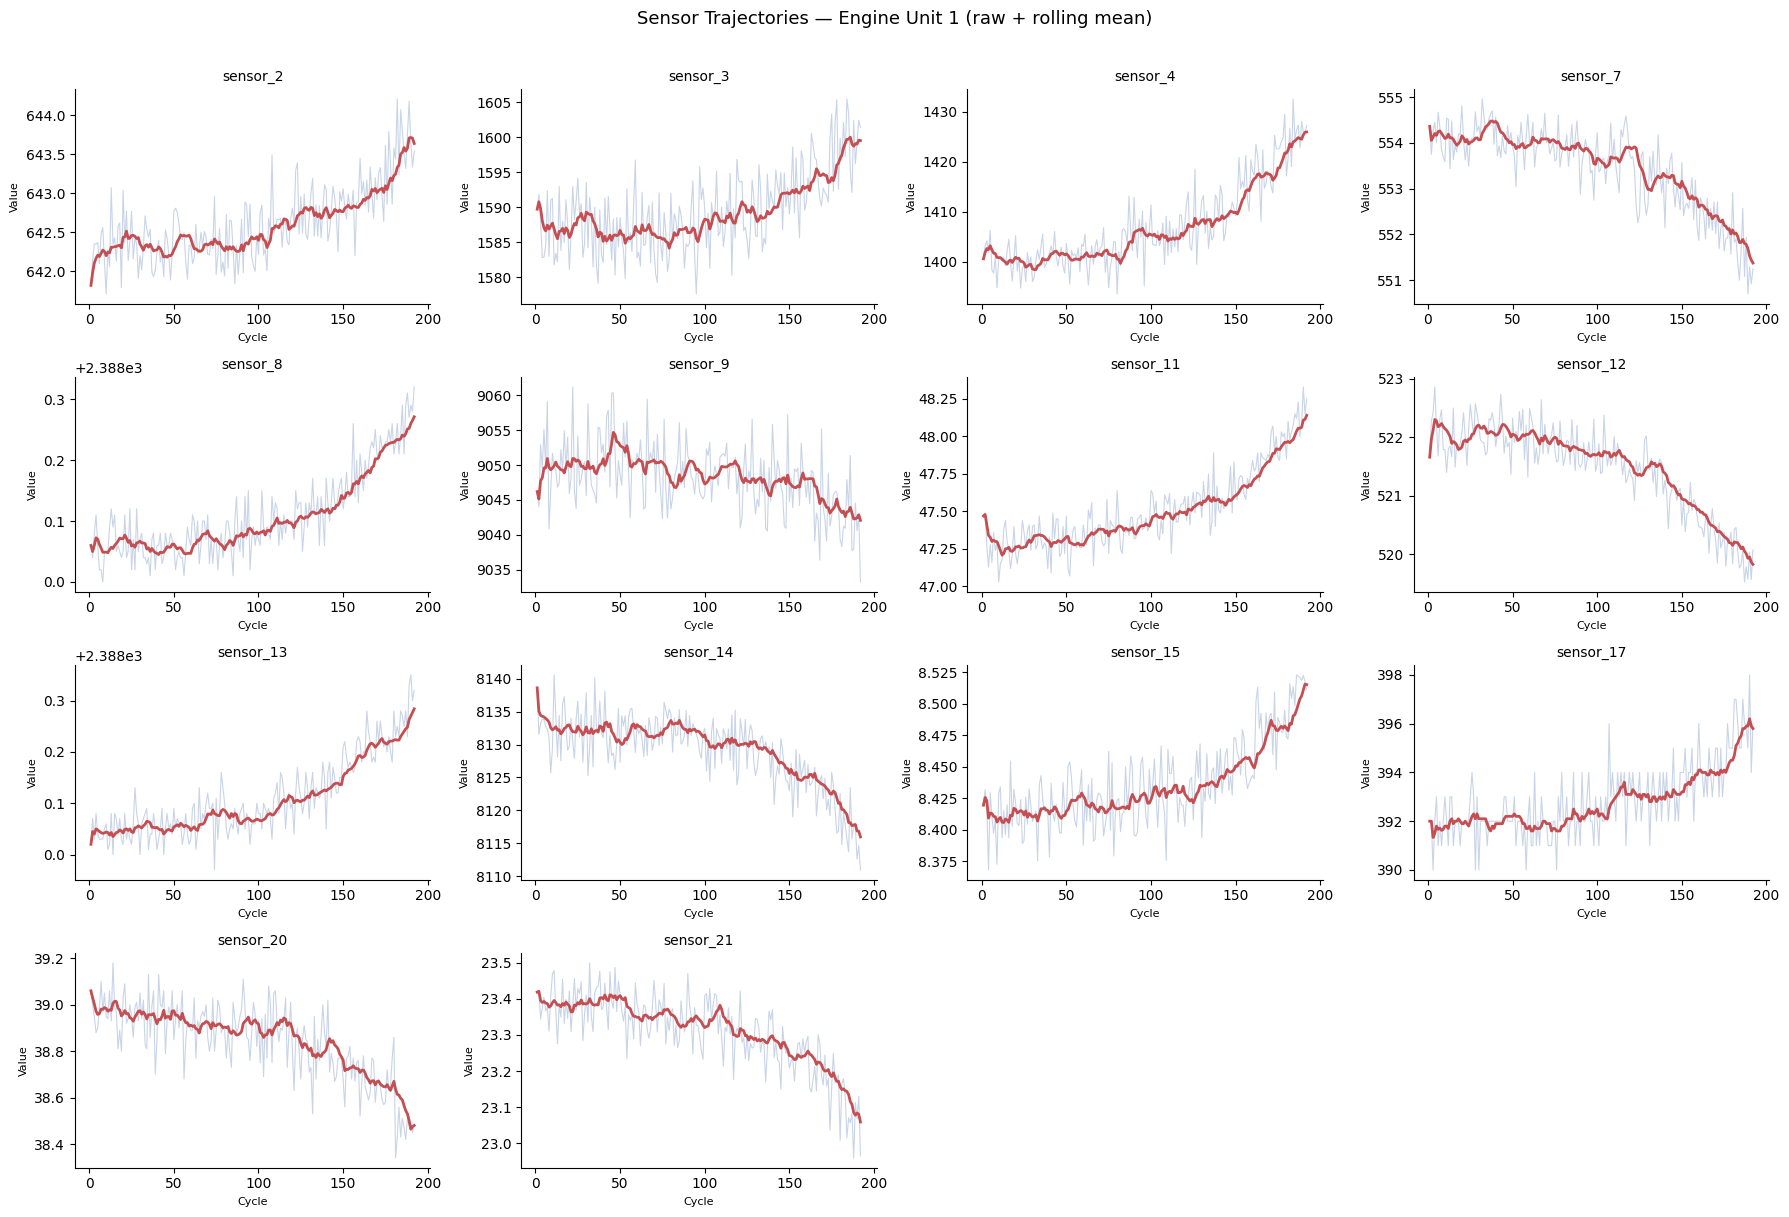

In [22]:
# Cell 8 — Sensor trajectories for a single engine
# Visualise how each selected sensor behaves over one engine's full lifetime
# Rolling mean added to reveal the underlying trend through sensor noise

import math

sensor_cols = config["selected_sensors"]
engine_data = train_df[train_df["unit"] == 1].copy()

n_cols = 4
n_rows = math.ceil(len(sensor_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, sensor in enumerate(sensor_cols):
    ax = axes[i]
    raw = engine_data[sensor]
    rolling_mean = raw.rolling(window=10, min_periods=1).mean()

    ax.plot(engine_data["cycle"], raw, alpha=0.3, color="#4C72B0", linewidth=0.8)
    ax.plot(engine_data["cycle"], rolling_mean, color="#C44E52", linewidth=2)
    ax.set_title(sensor, fontsize=10)
    ax.set_xlabel("Cycle", fontsize=8)
    ax.set_ylabel("Value", fontsize=8)

# Hide unused subplots
for j in range(len(sensor_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Sensor Trajectories — Engine Unit 1 (raw + rolling mean)", 
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

=== RUL DISTRIBUTION SUMMARY ===
       Train (all cycles)  Test (cutoff)
count            20631.00         100.00
mean               107.81          75.52
std                 68.88          41.76
min                  0.00           7.00
10%                 20.00          15.90
25%                 51.00          32.75
50%                103.00          86.00
75%                155.00         112.25
90%                198.00         126.20
max                361.00         145.00

=== LOWER-TAIL SHARE (own 10th percentile threshold) ===
Train tail share: 0.102
Test tail share : 0.100


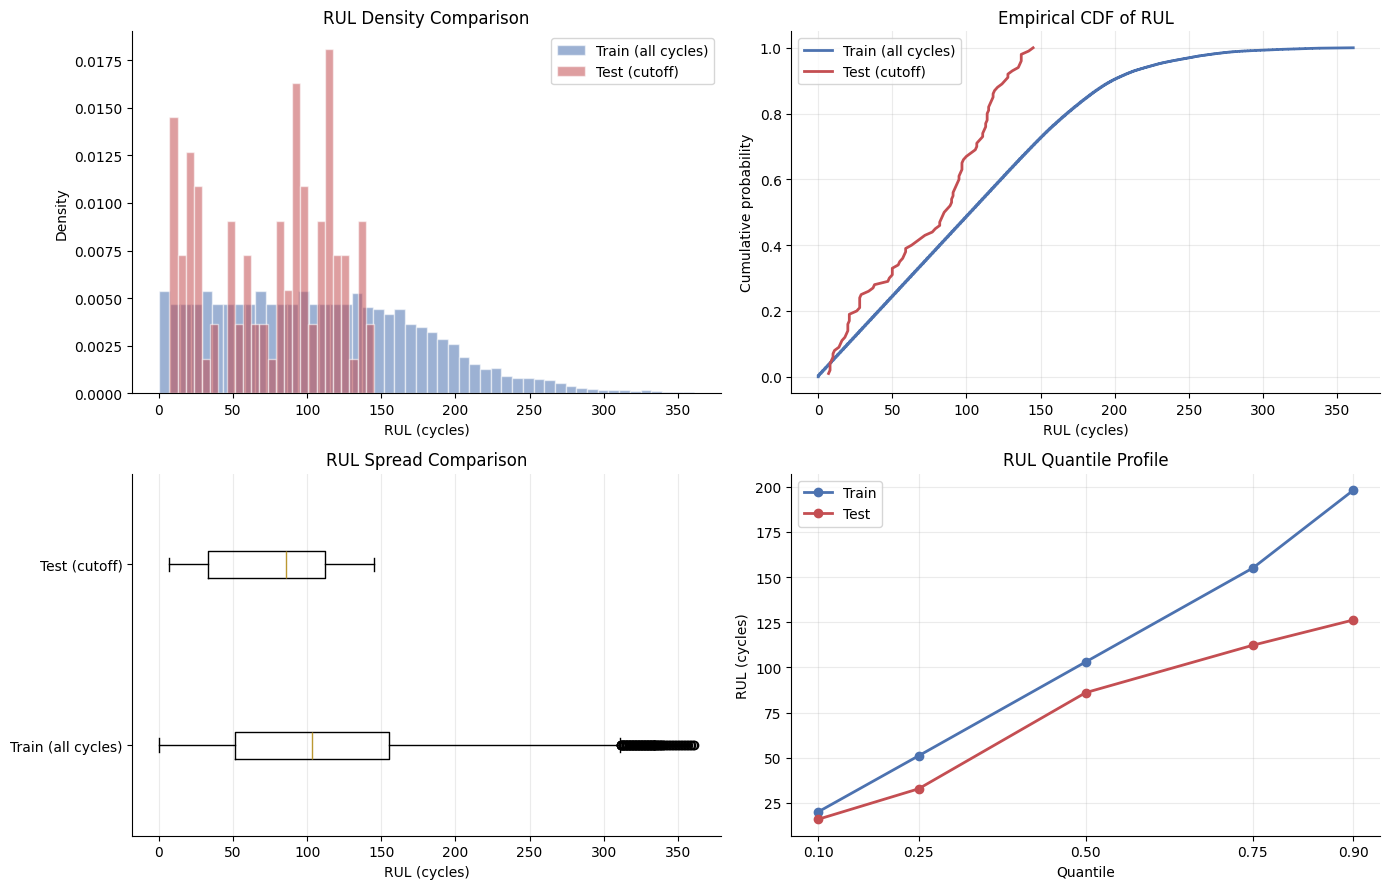


Interpretation guide:
- If train and test curves differ, the model sees a distribution shift from train cycles to test cutoffs.
- CDF separation at low RUL indicates different critical-window representation.
- Quantile gaps show where train/test mismatch is most pronounced (early-life vs late-life).


In [29]:
# Cell 9 — RUL distribution analysis (improved)
"""
Purpose: Compare train and test RUL distributions with multiple complementary views.
Input shape: train_df (all train cycles), rul (test-set cutoff RUL per engine).
Output shape: 2x2 figure + summary table for spread, skew, and tail behavior.
Assumptions: train_df has ['unit', 'cycle']; rul is a 1D Series of test RUL targets.
Failure conditions: Raises ValueError if required inputs are empty.
"""

if train_df.empty:
    raise ValueError("train_df is empty.")
if len(rul) == 0:
    raise ValueError("rul is empty.")

# Build per-cycle train RUL: RUL = max_cycle(unit) - current_cycle
max_cycles = train_df.groupby("unit", as_index=False)["cycle"].max().rename(columns={"cycle": "max_cycle"})
train_rul_df = train_df.merge(max_cycles, on="unit", how="left")
train_rul_df["rul"] = train_rul_df["max_cycle"] - train_rul_df["cycle"]

train_rul_all = train_rul_df["rul"].astype(float)
test_rul_cutoff = rul.astype(float)

# Summary stats for quick comparison
quantiles = [0.10, 0.25, 0.50, 0.75, 0.90]
summary = pd.DataFrame({
    "Train (all cycles)": train_rul_all.describe(percentiles=quantiles),
    "Test (cutoff)": test_rul_cutoff.describe(percentiles=quantiles),
}).round(2)

print("=== RUL DISTRIBUTION SUMMARY ===")
print(summary)

# Fraction of samples in lower RUL tail (critical region)
train_tail_ratio = (train_rul_all <= train_rul_all.quantile(0.10)).mean()
test_tail_ratio = (test_rul_cutoff <= test_rul_cutoff.quantile(0.10)).mean()
print("\n=== LOWER-TAIL SHARE (own 10th percentile threshold) ===")
print(f"Train tail share: {train_tail_ratio:.3f}")
print(f"Test tail share : {test_tail_ratio:.3f}")

# Visual diagnostics
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1) Overlay histogram (density-scaled)
axes[0, 0].hist(train_rul_all, bins=50, density=True, alpha=0.55, color="#4C72B0", edgecolor="white", label="Train (all cycles)")
axes[0, 0].hist(test_rul_cutoff, bins=25, density=True, alpha=0.55, color="#C44E52", edgecolor="white", label="Test (cutoff)")
axes[0, 0].set_title("RUL Density Comparison")
axes[0, 0].set_xlabel("RUL (cycles)")
axes[0, 0].set_ylabel("Density")
axes[0, 0].legend()

# 2) Empirical CDF comparison
train_sorted = np.sort(train_rul_all.values)
test_sorted = np.sort(test_rul_cutoff.values)
train_cdf = np.arange(1, len(train_sorted) + 1) / len(train_sorted)
test_cdf = np.arange(1, len(test_sorted) + 1) / len(test_sorted)
axes[0, 1].plot(train_sorted, train_cdf, color="#4C72B0", linewidth=2, label="Train (all cycles)")
axes[0, 1].plot(test_sorted, test_cdf, color="#C44E52", linewidth=2, label="Test (cutoff)")
axes[0, 1].set_title("Empirical CDF of RUL")
axes[0, 1].set_xlabel("RUL (cycles)")
axes[0, 1].set_ylabel("Cumulative probability")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.25)

# 3) Boxplot for spread/outliers comparison
axes[1, 0].boxplot([train_rul_all.values, test_rul_cutoff.values],
                   tick_labels=["Train (all cycles)", "Test (cutoff)"],
                   vert=False,
                   showfliers=True)
axes[1, 0].set_title("RUL Spread Comparison")
axes[1, 0].set_xlabel("RUL (cycles)")
axes[1, 0].grid(axis="x", alpha=0.25)

# 4) Quantile profile comparison
q_levels = np.array([0.10, 0.25, 0.50, 0.75, 0.90])
train_q = train_rul_all.quantile(q_levels)
test_q = test_rul_cutoff.quantile(q_levels)
axes[1, 1].plot(q_levels, train_q.values, marker="o", color="#4C72B0", linewidth=2, label="Train")
axes[1, 1].plot(q_levels, test_q.values, marker="o", color="#C44E52", linewidth=2, label="Test")
axes[1, 1].set_title("RUL Quantile Profile")
axes[1, 1].set_xlabel("Quantile")
axes[1, 1].set_ylabel("RUL (cycles)")
axes[1, 1].set_xticks(q_levels)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("\nInterpretation guide:")
print("- If train and test curves differ, the model sees a distribution shift from train cycles to test cutoffs.")
print("- CDF separation at low RUL indicates different critical-window representation.")
print("- Quantile gaps show where train/test mismatch is most pronounced (early-life vs late-life).")

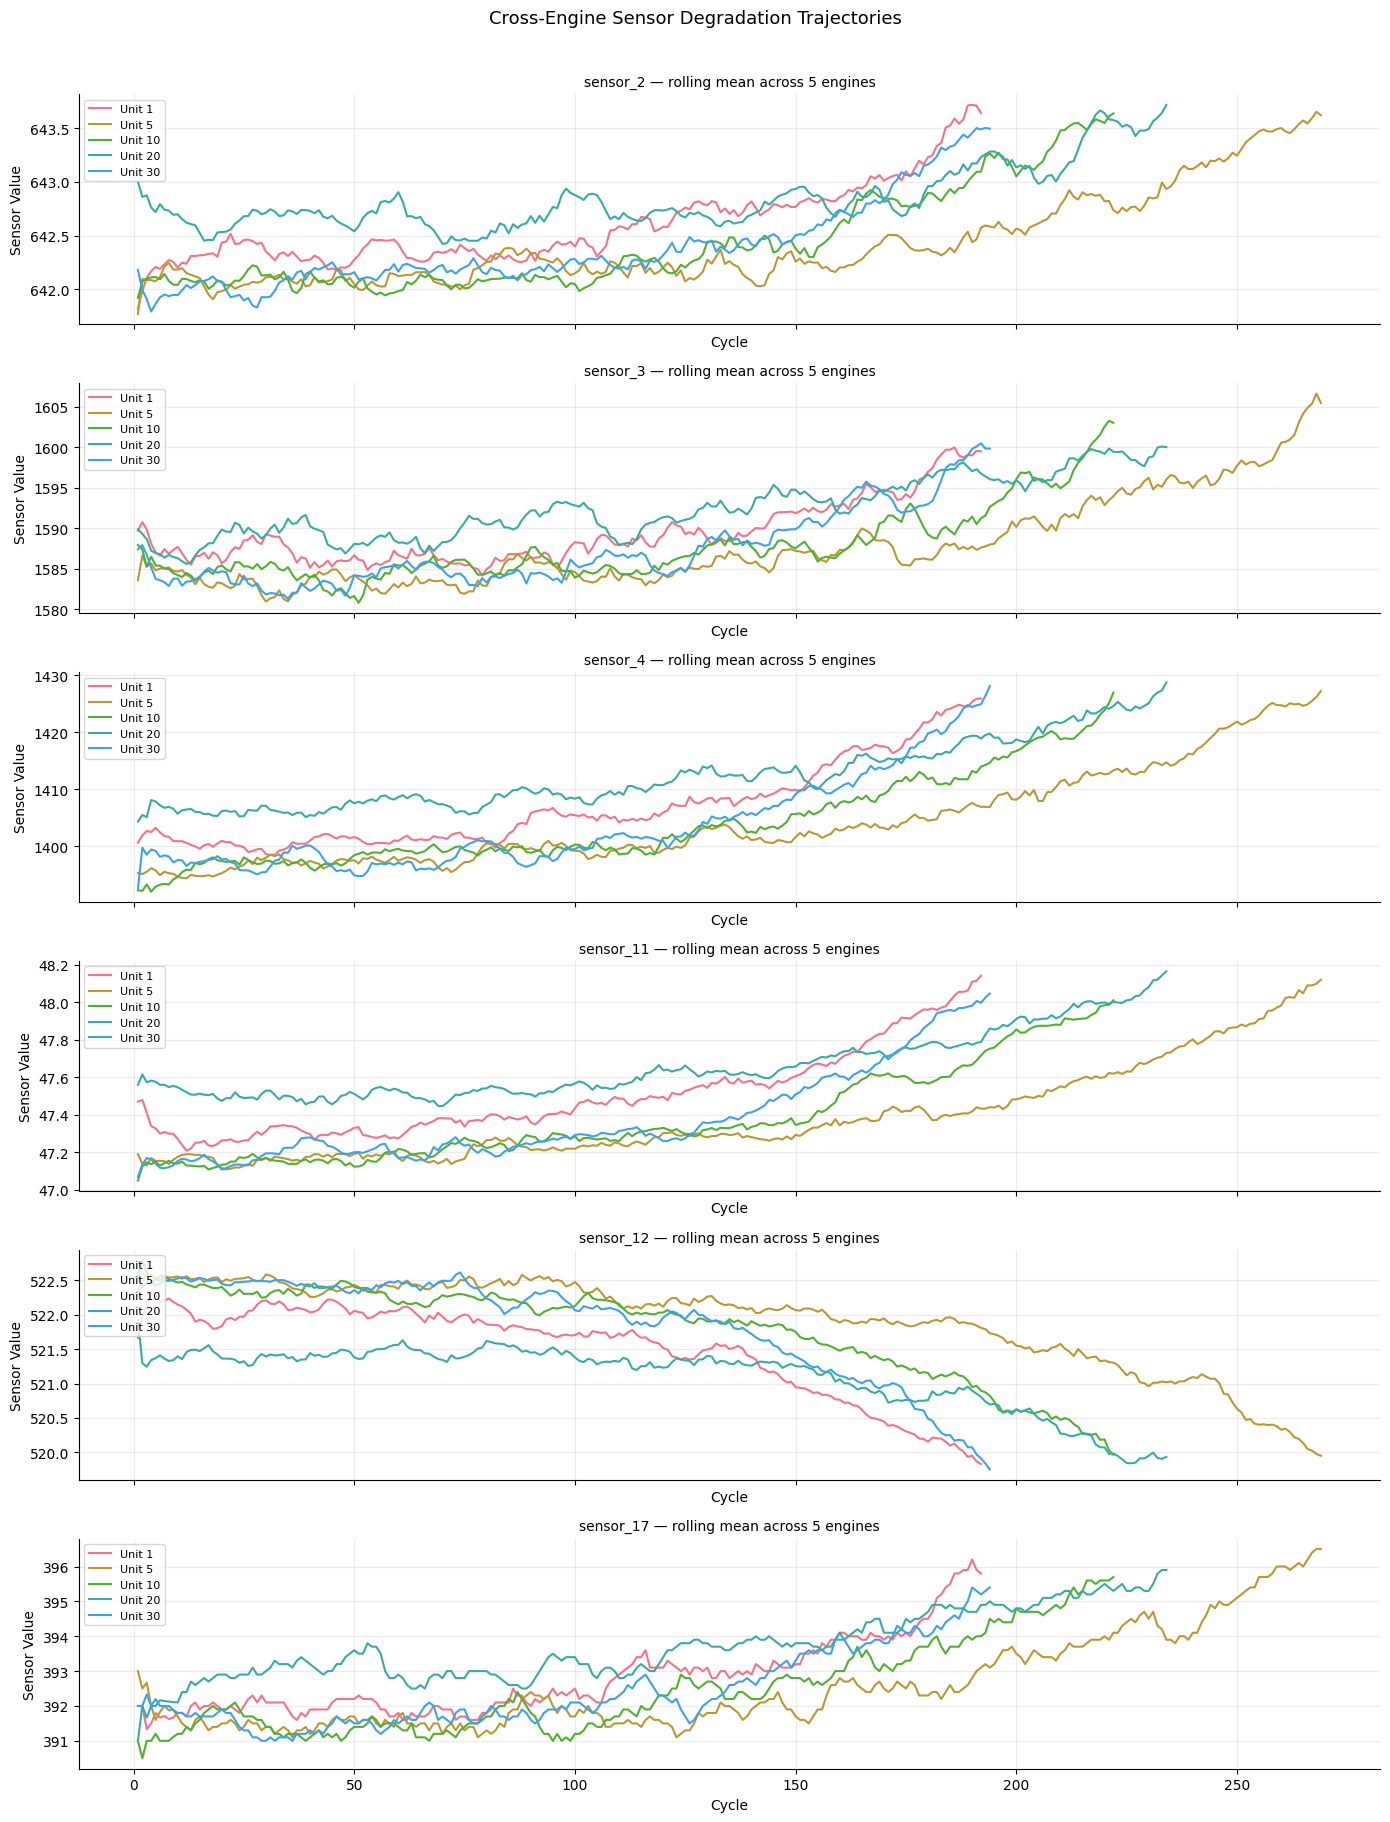

In [30]:
# Cell 10 — Sensor trajectories across multiple engines
"""
Purpose: Compare rolling sensor degradation trajectories across multiple engines.
Input shape: train_df with columns ['unit', 'cycle', sensor columns].
Output shape: One subplot per selected sensor, one line per selected engine.
Assumptions: Engine units and sensor columns exist in train_df.
Failure conditions: Raises ValueError if requested units/sensors are missing.
"""

# Compare how selected sensors degrade across different engines.
# This validates that degradation is consistent across the fleet,
# not just an artefact of one engine's data.

sample_engines = [1, 5, 10, 20, 30]
requested_sensors = ["sensor_2", "sensor_3", "sensor_4", "sensor_11", "sensor_12", "sensor_17"]

# Normalize sensor names to dataset schema (e.g., sensor_2 -> s2)
def _normalize_sensor_name(sensor_name: str) -> str:
    if sensor_name in train_df.columns:
        return sensor_name
    if sensor_name.startswith("sensor_"):
        candidate = f"s{sensor_name.split('_')[-1]}"
        if candidate in train_df.columns:
            return candidate
    return sensor_name

sensors_to_plot = [_normalize_sensor_name(sensor) for sensor in requested_sensors]

available_units = set(train_df["unit"].unique())
missing_units = [unit for unit in sample_engines if unit not in available_units]
if missing_units:
    raise ValueError(f"Units not found in train_df: {missing_units}")

missing_sensors = [sensor for sensor in sensors_to_plot if sensor not in train_df.columns]
if missing_sensors:
    raise ValueError(f"Sensors not found in train_df: {missing_sensors}")

fig, axes = plt.subplots(len(sensors_to_plot), 1, figsize=(14, len(sensors_to_plot) * 3), sharex=True)

if len(sensors_to_plot) == 1:
    axes = [axes]

for i, sensor in enumerate(sensors_to_plot):
    ax = axes[i]
    for unit in sample_engines:
        engine_data = train_df[train_df["unit"] == unit].copy().sort_values("cycle")
        rolling = engine_data[sensor].rolling(window=10, min_periods=1).mean()
        ax.plot(engine_data["cycle"], rolling, linewidth=1.5, label=f"Unit {unit}")

    ax.set_title(f"{sensor} — rolling mean across 5 engines", fontsize=10)
    ax.set_xlabel("Cycle")
    ax.set_ylabel("Sensor Value")
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(alpha=0.25)

plt.suptitle("Cross-Engine Sensor Degradation Trajectories", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

=== CROSS-ENGINE TREND CONSISTENCY ===
      sensor expected_direction  consistency_pct  mean_slope  std_slope
0   sensor_2               down              0.0     0.00521    0.00128
1   sensor_3               down              0.0     0.05758    0.00757
2   sensor_4               down              0.0     0.10658    0.01671
3  sensor_11               down              0.0     0.00323    0.00063
4  sensor_12                 up              0.0    -0.00887    0.00228
5  sensor_17               down              0.0     0.01579    0.00189


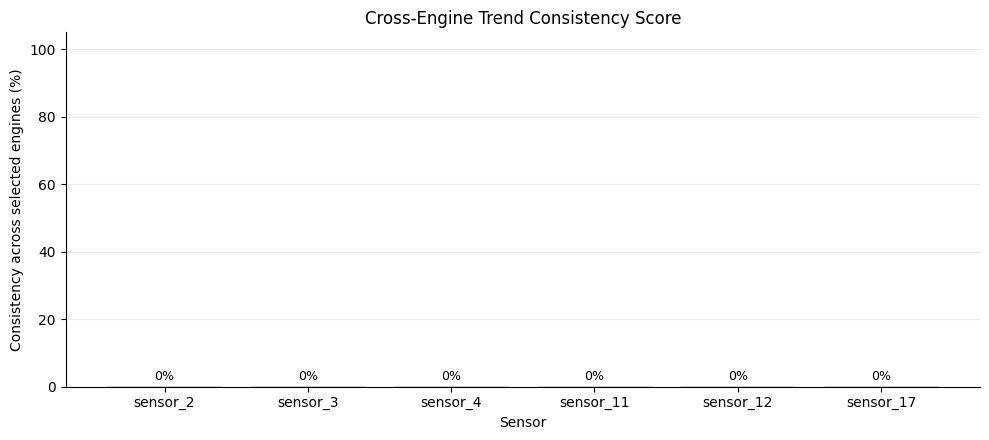

In [ ]:
# Cell 11 — Cross-engine trend consistency score
"""
Purpose: Quantify whether each selected sensor follows a consistent degradation direction across engines.
Input shape: train_df with ['unit', 'cycle', sensor columns]; uses sample_engines/sensors_to_plot from Cell 10 when available.
Output shape: Summary table + bar plot of consistency percentage per sensor.
Assumptions: Each selected engine has at least two cycle points.
Failure conditions: Raises ValueError if required sensors/engines are unavailable.
"""

# Reuse Cell 10 selections if present; otherwise set defaults
if "sample_engines" not in locals():
    sample_engines = [1, 5, 10, 20, 30]
if "sensors_to_plot" not in locals():
    sensors_to_plot = ["s2", "s3", "s4", "s11", "s12", "s17"]

available_units = set(train_df["unit"].unique())
missing_units = [unit for unit in sample_engines if unit not in available_units]
if missing_units:
    raise ValueError(f"Units not found in train_df: {missing_units}")

missing_sensors = [sensor for sensor in sensors_to_plot if sensor not in train_df.columns]
if missing_sensors:
    raise ValueError(f"Sensors not found in train_df: {missing_sensors}")

rows = []
for sensor in sensors_to_plot:
    # Expected trend over cycle inferred from Cell 7 correlation with RUL:
    # if corr(sensor, RUL) < 0, sensor should increase as cycle grows (up trend), and vice versa.
    if "correlations" in locals() and sensor in correlations.index:
        expected_sign = -np.sign(correlations[sensor])
    else:
        expected_sign = 0.0

    sensor_slopes = []
    for unit in sample_engines:
        engine_data = train_df.loc[train_df["unit"] == unit, ["cycle", sensor]].sort_values("cycle")
        rolling = engine_data[sensor].rolling(window=10, min_periods=1).mean()
        slope = np.polyfit(engine_data["cycle"].values, rolling.values, 1)[0]
        sensor_slopes.append(slope)

    sensor_slopes = np.array(sensor_slopes, dtype=float)

    if expected_sign == 0:
        # If no expected sign available, use majority sign among slopes
        expected_sign = np.sign(np.nanmedian(sensor_slopes))

    matches = np.sign(sensor_slopes) == expected_sign
    consistency_pct = 100.0 * matches.mean()

    rows.append({
        "sensor": sensor,
        "expected_direction": "up" if expected_sign > 0 else "down",
        "consistency_pct": consistency_pct,
        "mean_slope": sensor_slopes.mean(),
        "std_slope": sensor_slopes.std(ddof=1) if len(sensor_slopes) > 1 else 0.0,
    })

consistency_df = pd.DataFrame(rows).sort_values("consistency_pct", ascending=False)

print("=== CROSS-ENGINE TREND CONSISTENCY ===")
print(consistency_df.round({"consistency_pct": 1, "mean_slope": 5, "std_slope": 5}))

fig, ax = plt.subplots(figsize=(10, 4.5))
bar_colors = ["#4C72B0" if direction == "up" else "#C44E52" for direction in consistency_df["expected_direction"]]
ax.bar(consistency_df["sensor"], consistency_df["consistency_pct"], color=bar_colors, edgecolor="black", alpha=0.8)
ax.set_ylim(0, 105)
ax.set_ylabel("Consistency across selected engines (%)")
ax.set_xlabel("Sensor")
ax.set_title("Cross-Engine Trend Consistency Score")
ax.grid(axis="y", alpha=0.25)

for idx, val in enumerate(consistency_df["consistency_pct"]):
    ax.text(idx, val + 1.2, f"{val:.0f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()